# Life Expectancy and GDP Project

## import necessary libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

## Load the data

In [2]:
gdp_data = pd.read_csv("all_data.csv")

## Inspect the data

In [3]:
print(gdp_data.head())

  Country  Year  Life expectancy at birth (years)           GDP
0   Chile  2000                              77.3  7.786093e+10
1   Chile  2001                              77.3  7.097992e+10
2   Chile  2002                              77.8  6.973681e+10
3   Chile  2003                              77.9  7.564346e+10
4   Chile  2004                              78.0  9.921039e+10


In [4]:
gdp_data.describe()

,Year,Life expectancy at birth (years),GDP
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


In [5]:
gdp_data.info()
gdp_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


(96, 4)

### Conclusions
- There are no null values
- There are four variables
- There are 96 rows
- GDP Values are huge

## Make the display more readable

In [6]:
pd.options.display.float_format = '{:.0f}'.format

In [7]:
print(gdp_data.head())

  Country  Year  Life expectancy at birth (years)         GDP
0   Chile  2000                                77 77860932152
1   Chile  2001                                77 70979923960
2   Chile  2002                                78 69736811435
3   Chile  2003                                78 75643459840
4   Chile  2004                                78 99210392858


## Rename the life expectancy column

In [8]:
gdp_data = gdp_data.rename(columns={"Life expectancy at birth (years)": "Life_expectancy"})

## Get an overview of the categorical values

In [9]:
print(gdp_data.Country.unique())

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']


### Conclusion
- There are 6 different countries
- There are 5 different continents:
    - North America
    - South America
    - Europe
    - Asia
    - Africa
- Counties differ in Development: according to the UN, we would categorize them as follows:
    - Developed Economies: Germany, China, United States of America
    - Developing Economies: Mexico
    - Least Developed Economies: Zimbabwe

## Adding Columns

### Adding Column for economic development

In [10]:
def classify_economic_development(df, country_names):
    # Initialize the 'economic development' column
    df['Economic_development'] = None
    
    for country_name in country_names:
        if country_name == "Germany" or country_name == "United States of America" or country_name == "China":
            # Set the value for Developed Economy
            df.loc[df['Country'] == country_name, 'Economic_development'] = "Developed Economy"
        elif country_name == "Mexico" or country_name == "Chile":
            # Set the value for Developing Economy
            df.loc[df['Country'] == country_name, 'Economic_development'] = "Developing Economy"
        else:
            # Set the value for Least Developed Economy
            df.loc[df['Country'] == country_name, 'Economic_development'] = "Least Developed Economy"
    
    return df

gdp_data = classify_economic_development(gdp_data, gdp_data.Country)

### Adding Column for continent development

In [11]:
def classify_continent(df, country_names):
    df['Continent'] = None
    #same as prior function just for continents
    for country_name in country_names:
        if country_name == "Germany":
            df.loc[df['Country'] == country_name, 'Continent'] = "Europe"
        elif country_name == "Mexico" or country_name == "United States of America":
            df.loc[df['Country'] == country_name, 'Continent'] = "North America"
        elif country_name == "China":
            df.loc[df["Country"] == country_name, "Continent"] = "Asia"
        elif country_name == "Chile":
            df.loc[df["Country"] == country_name, "Continent"] = "South America"
        else:
            df.loc[df['Country'] == country_name, 'Continent'] = "Africa"
    
    return df

gdp_data = classify_continent(gdp_data, gdp_data.Country)

In [12]:
print(gdp_data.head())

  Country  Year  Life_expectancy         GDP Economic_development  \
0   Chile  2000               77 77860932152   Developing Economy   
1   Chile  2001               77 70979923960   Developing Economy   
2   Chile  2002               78 69736811435   Developing Economy   
3   Chile  2003               78 75643459840   Developing Economy   
4   Chile  2004               78 99210392858   Developing Economy   

       Continent  
0  South America  
1  South America  
2  South America  
3  South America  
4  South America  


## Statistical summmary

### correlations between development of economy and gdp

In [13]:
#ordinal encoding for development
category_map = {'Least Developed Economy': 0, 'Developing Economy': 1, 'Developed Economy': 2}
gdp_data['Economic_development_encoded'] = gdp_data['Economic_development'].map(category_map)

In [14]:
correlation = gdp_data['Economic_development_encoded'].corr(gdp_data['GDP'])
print(correlation)

0.6209203478346033


### correlations between life expectancy and GDP

In [15]:
correlation = gdp_data['Life_expectancy'].corr(gdp_data['GDP'])
print(correlation)

0.3432067484491559


### correlations between development of economy and life expectancy

In [16]:
correlation = gdp_data['Economic_development_encoded'].corr(gdp_data['Life_expectancy'])
print(correlation)

0.7646864764323289


### conclusions
- Correlation between UN economic Development and GDP is high but not as high as one would expect since both are economy measures
    - possible explanation: GDP is not standardized by country size
- Low correlation between Life expectancy and GDP
    - possible explanations: GDP is not standardized by country size, even strong countries could be poorin healthcare or social welfaire
- High correlation between Economic Development and life expectancy
 - possible explanations: GDP is not standardized by country size, UN classification includes other measures that are not economic

## Data visualization

### Exploratory plots

Text(0.5, 0.98, 'GDP and Life Expectancy by Country')

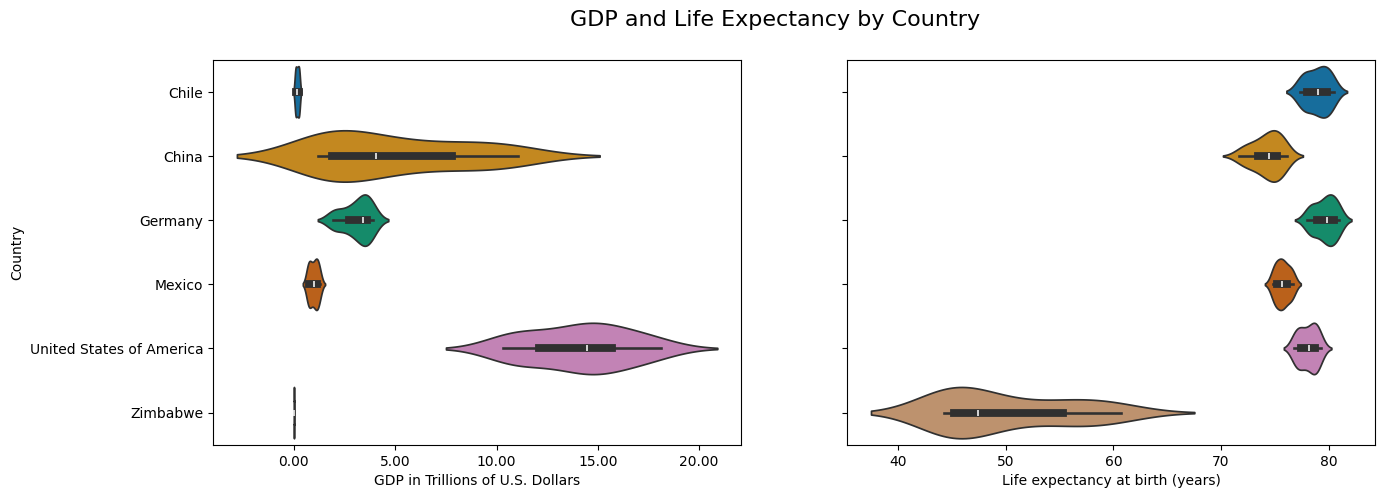

In [17]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15, 5))
axes[0] = sns.violinplot(ax=axes[0], x=gdp_data.GDP, y=gdp_data.Country, hue=gdp_data.Country, palette="colorblind")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))
axes[0].set_xlabel("GDP in Trillions of U.S. Dollars")
axes[1] = sns.violinplot(ax=axes[1], x=gdp_data.Life_expectancy, y=gdp_data.Country, hue= gdp_data.Country, palette="colorblind")
axes[1].set_xlabel("Life expectancy at birth (years)");
fig.suptitle("GDP and Life Expectancy by Country", fontsize=16)

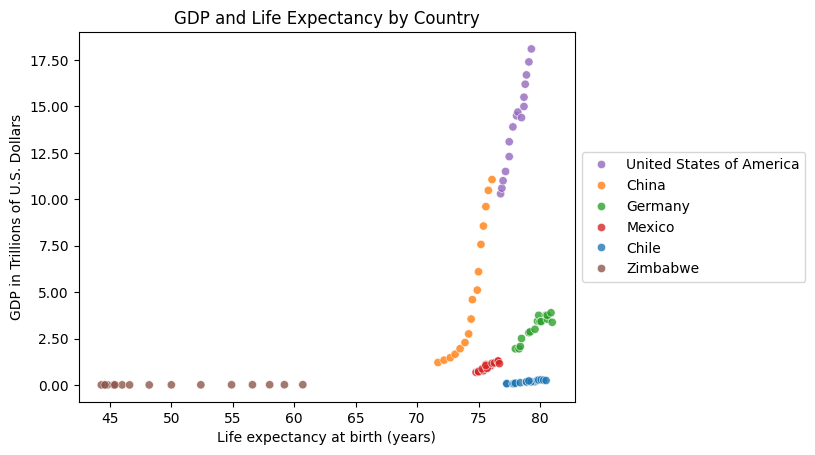

<Figure size 640x480 with 0 Axes>

In [18]:
ax = sns.scatterplot(x=gdp_data.Life_expectancy, y=gdp_data.GDP, hue=gdp_data.Country, alpha = 0.8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))
ax.set_xlabel("Life expectancy at birth (years)")
ax.set_ylabel("GDP in Trillions of U.S. Dollars")
handles, labels = ax.get_legend_handles_labels()
new_order = [handles[4], handles[1], handles[2], handles[3], handles[0], handles[5]]  # Example of changing order
new_labels = [labels[4], labels[1], labels[2], labels[3], labels[0], labels[5]]
plt.legend(new_order, new_labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.title("GDP and Life Expectancy by Country")
plt.show()
plt.clf()

### conclusions
- There is a relationship between GDP and Life expectancy
- GDP data in China and the U.S. is very spread
- Life expectancy data in Zimbabwe is very spread
- The highest life expectancy in Zimbabwe is still below the lowest life expectancy of the other countries

### Overall Life expectancy over the past 6 years

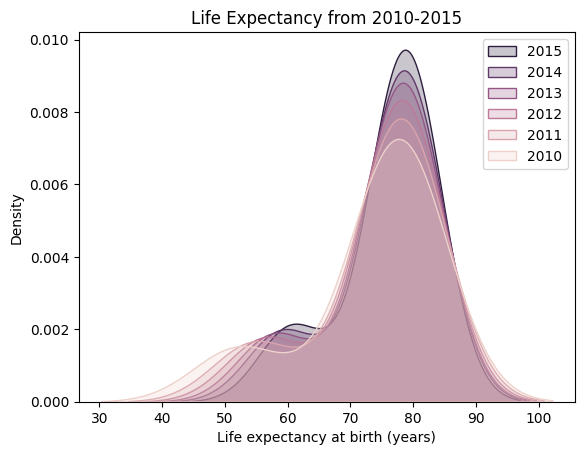

<Figure size 640x480 with 0 Axes>

In [19]:
current_gdp_data = gdp_data[gdp_data["Year"] >= 2010]
sns.kdeplot(data=current_gdp_data, x="Life_expectancy", hue="Year", fill=True)
plt.legend(["2015", "2014","2013", "2012","2011", "2010"])
plt.xlabel("Life expectancy at birth (years)")
plt.title("Life Expectancy from 2010-2015")
plt.show()
plt.clf()

### conclusions
- The density oflife expectancy between approx. 75 and 90 years has risen over the past 6 years

### Development of GDP over time

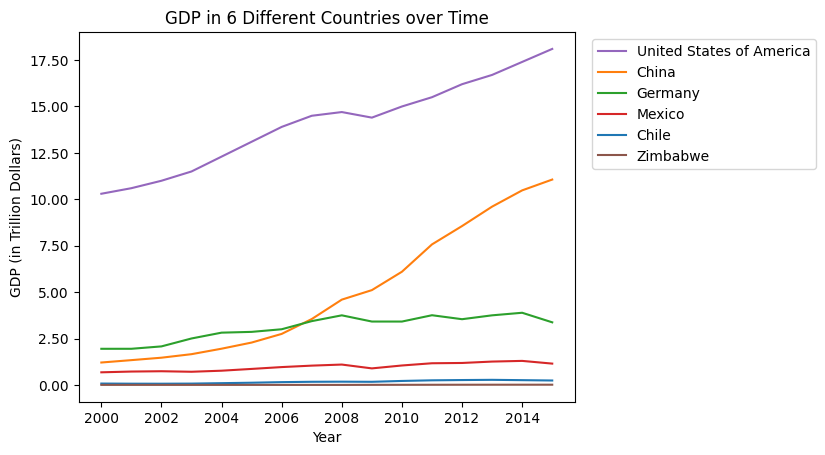

<Figure size 640x480 with 0 Axes>

In [20]:
ax = sns.lineplot(x=gdp_data.Year, y=gdp_data.GDP, hue=gdp_data.Country)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))
ax.set_ylabel("GDP (in Trillion Dollars)")

plt.title("GDP in 6 Different Countries over Time")
handles, labels = ax.get_legend_handles_labels()

# Reorder the legend manually (for example, reversing the order)
# You can specify the order you want here
new_order = [handles[4], handles[1], handles[2], handles[3], handles[0], handles[5]]  # Example of changing order
new_labels = [labels[4], labels[1], labels[2], labels[3], labels[0], labels[5]]
ax.legend(new_order, new_labels, loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()
plt.clf()

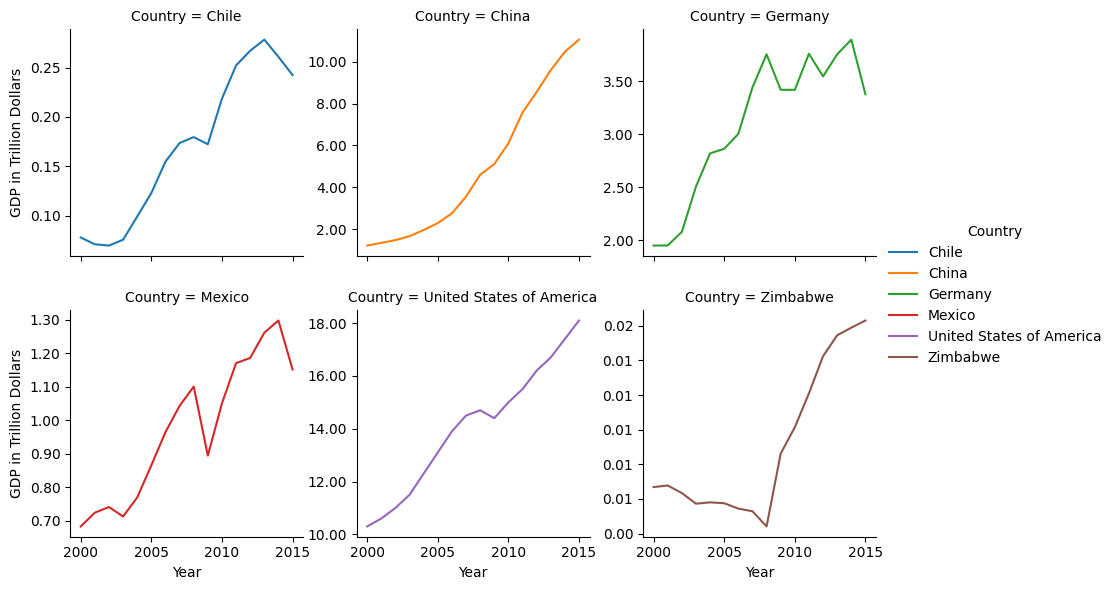

In [21]:
gdp_graphs = sns.FacetGrid(gdp_data, col="Country", col_wrap=3,
                      hue = "Country", sharey = False)

gdp_graphs = (gdp_graphs.map(sns.lineplot,"Year","GDP")
         .add_legend()
         .set_axis_labels("Year","GDP in Trillion Dollars"))

#Format y-axis for each subplot
for ax in gdp_graphs.axes.flat:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))

gdp_graphs;

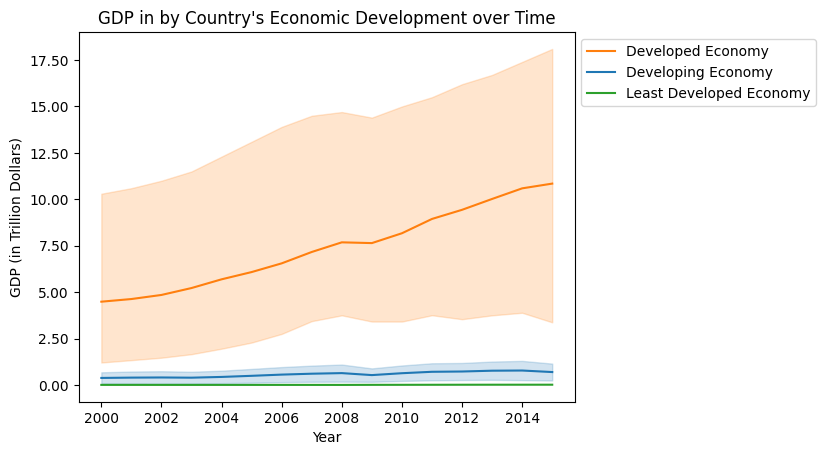

<Figure size 640x480 with 0 Axes>

In [22]:
ax = sns.lineplot(x=gdp_data.Year, y=gdp_data.GDP, hue=gdp_data.Economic_development)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))
ax.set_ylabel("GDP (in Trillion Dollars)")

plt.title("GDP in by Country's Economic Development over Time")
handles, labels = ax.get_legend_handles_labels()

# Reorder the legend manually (for example, reversing the order)
# You can specify the order you want here
new_order = [handles[1], handles[0], handles[2]]  # Example of changing order
new_labels = [labels[1], labels[0], labels[2]]
ax.legend(new_order, new_labels, loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()
plt.clf()

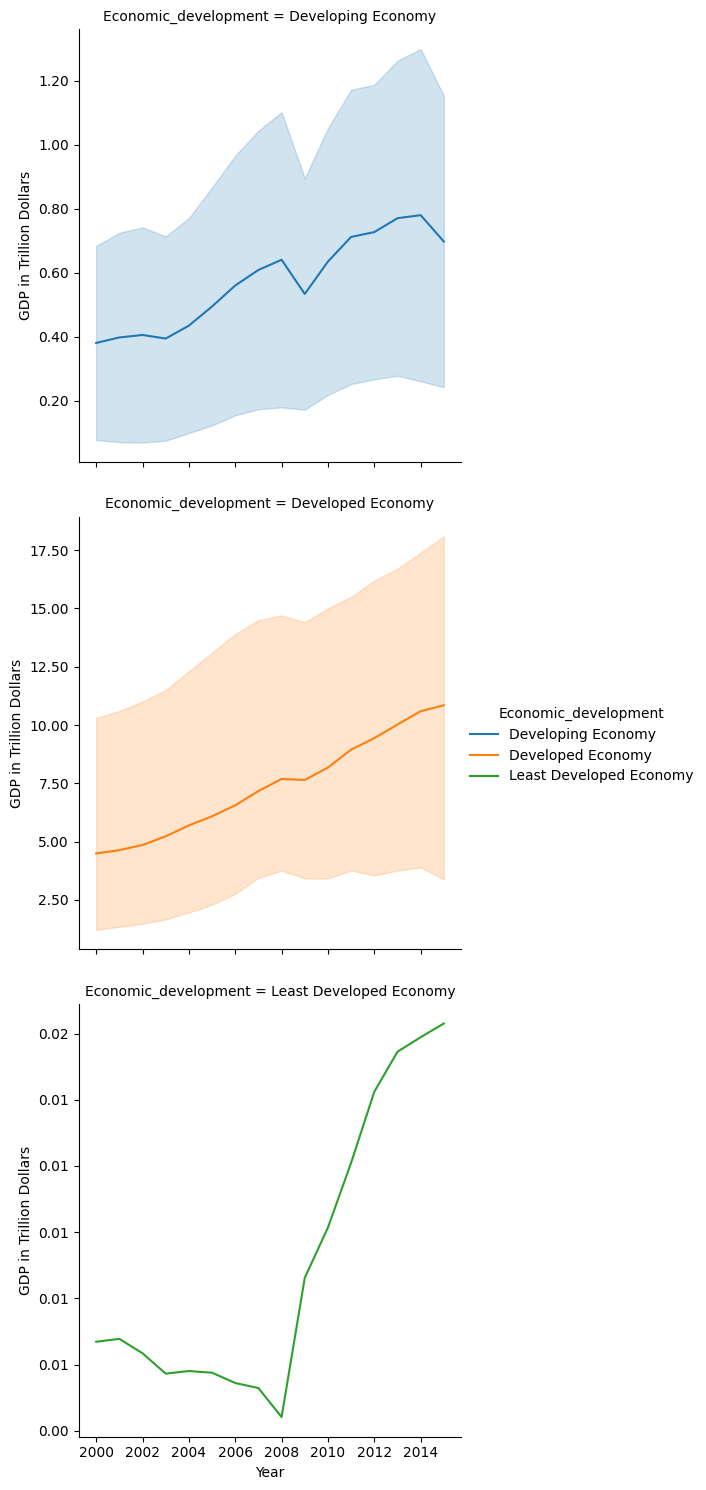

In [23]:
gdp_graphs = sns.FacetGrid(gdp_data, col="Economic_development", col_wrap=1,
                      hue = "Economic_development", sharey = False, height=5)

gdp_graphs = (gdp_graphs.map(sns.lineplot,"Year","GDP")
         .add_legend()
         .set_axis_labels("Year","GDP in Trillion Dollars"))

#Format y-axis for each subplot
for ax in gdp_graphs.axes.flat:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value / 1e12:.2f}"))

gdp_graphs;

### conclusions
- GDP in China and the U.S. is the highest, in the rest of the countries it is much smaller
- When looking closely at each country, it becomes salient, that each country had a strong uprise when comparing to previous values
    - e.g. Zimbabwes GDP doubled when year 2000 and 2015 are compared
    - China and the U.S. experienced and almost linear upward trend, the trends in the other countries were more complex
- when looking at the countries classified by economic development, it becomes salient that the most developed ones have the highest GDP

### Development of Life Expectancy over Time by Country

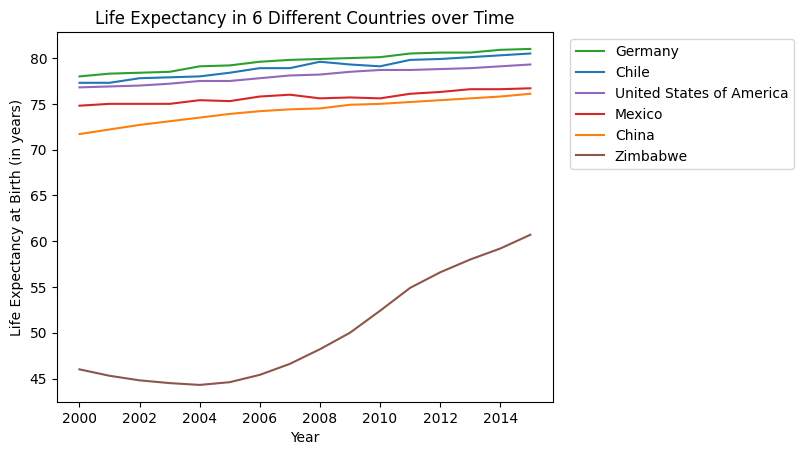

<Figure size 640x480 with 0 Axes>

In [24]:
ax = sns.lineplot(x=gdp_data.Year, y=gdp_data.Life_expectancy, hue=gdp_data.Country)
ax.set_ylabel("Life Expectancy at Birth (in years)")

plt.title("Life Expectancy in 6 Different Countries over Time")
handles, labels = ax.get_legend_handles_labels()

# Reorder the legend manually (for example, reversing the order)
# You can specify the order you want here
new_order = [handles[2], handles[0], handles[4], handles[3], handles[1], handles[5]]  # Example of changing order
new_labels = [labels[2], labels[0], labels[4], labels[3], labels[1], labels[5]]
ax.legend(new_order, new_labels, loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()
plt.clf()

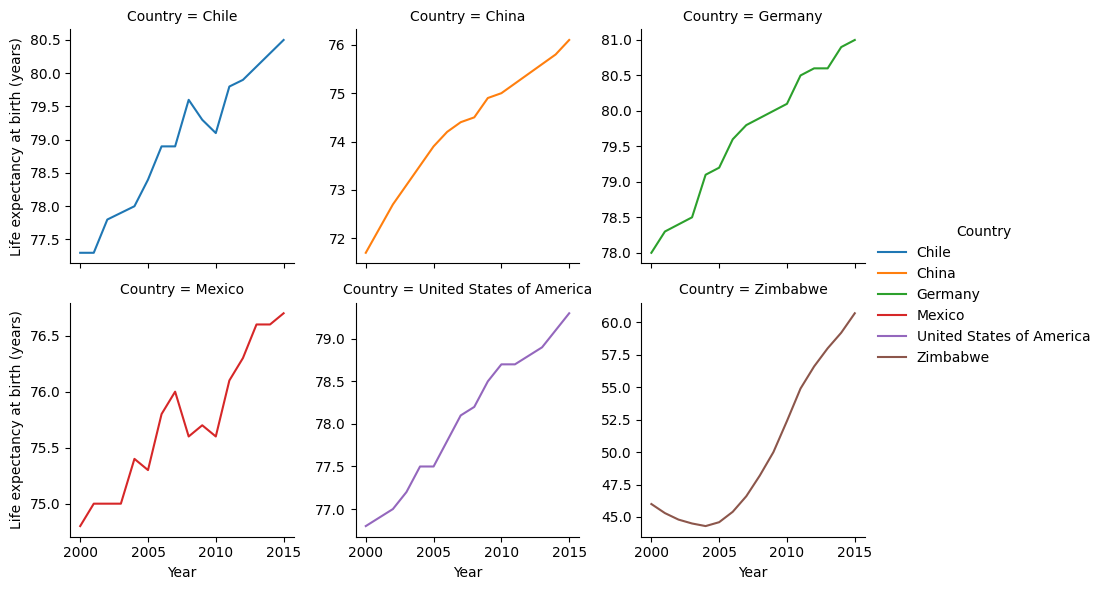

In [25]:
life_expectancy_graphs = sns.FacetGrid(gdp_data, col="Country", col_wrap=3,
                      hue = "Country", sharey = False)

life_expectancy_graphs = (life_expectancy_graphs.map(sns.lineplot,"Year","Life_expectancy")
         .add_legend()
         .set_axis_labels("Year","Life expectancy at birth (years)"))

life_expectancy_graphs;

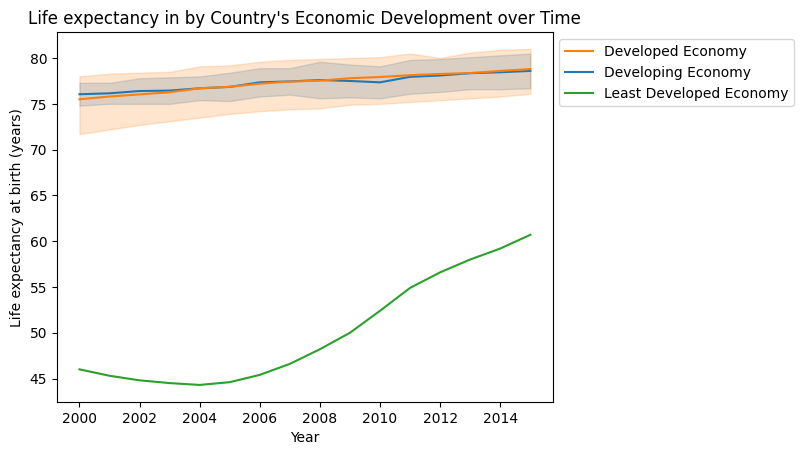

<Figure size 640x480 with 0 Axes>

In [26]:
ax = sns.lineplot(x=gdp_data.Year, y=gdp_data.Life_expectancy, hue=gdp_data.Economic_development)
ax.set_ylabel("Life expectancy at birth (years)")

plt.title("Life expectancy in by Country's Economic Development over Time")
handles, labels = ax.get_legend_handles_labels()

# Reorder the legend manually (for example, reversing the order)
# You can specify the order you want here
new_order = [handles[1], handles[0], handles[2]]  # Example of changing order
new_labels = [labels[1], labels[0], labels[2]]
ax.legend(new_order, new_labels, loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()
plt.clf()

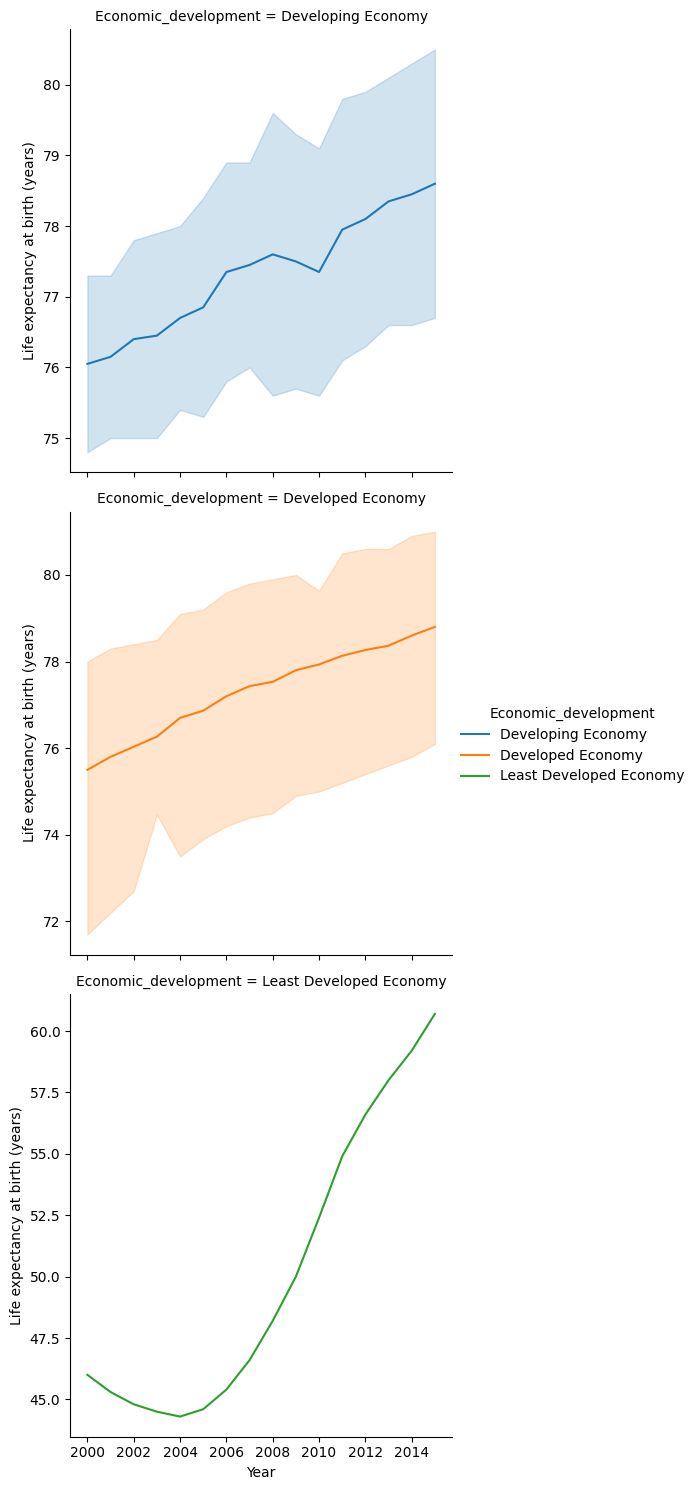

In [27]:
life_expectancy_graphs = sns.FacetGrid(gdp_data, col="Economic_development", col_wrap=1,
                      hue = "Economic_development", sharey = False, height=5, aspect=1)

life_expectancy_graphs = (life_expectancy_graphs.map(sns.lineplot,"Year","Life_expectancy")
         .add_legend()
         .set_axis_labels("Year","Life expectancy at birth (years)"))

life_expectancy_graphs;

### conclusions
- Life expectancy in Germany is the highest, but in the rest of the countries (except Zimbabwe) it is similar
- When looking closely at each country, it becomes salient, that each country had an uprise when comparing to previous values
    - e.g. Zimbabwes life expectancy rose from approx. 46 in 2000 to approx. 60 in 2015
    - in the remaining countries the rise is not as strong, as they started with a high life expectancy in 2000, e.g. in Germany aprox. 78
- when looking at the countries classified by economic development, it becomes salient that the most developed ones have the highest Life expectancy